In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Phase 2 data plumbing (reused)
# -------------------------------
from phase_2.utils.paths import PROCESSED_DIR
from phase_2.scripts.ingest.ingest_yahoo_multi_v1 import ingest_symbols
from phase_2.scripts.clean_validate.clean_validate_daily_v1 import process_all_symbols


In [13]:
# -------------------------------
# Phase 4 asset universe
# -------------------------------
SYMBOLS = [
    "SPY", "QQQ", "IWM",
    "AAPL", "MSFT", "NVDA",
    "XLU", "XLV", "XLP",
    "XLF", "XLE", "XLI",
]

START_DATE = "2010-01-01"


In [14]:
# -------------------------------
# 1. Ingest raw OHLCV data
# -------------------------------
ingest_symbols(
    symbols=SYMBOLS,
    start=START_DATE,
)

# -------------------------------
# 2. Clean + validate to daily parquet
# -------------------------------
process_all_symbols(
    symbols=SYMBOLS,
)


Saved SPY raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/spy_yahoo_raw.parquet (rows=4029)
Saved QQQ raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/qqq_yahoo_raw.parquet (rows=4029)
Saved IWM raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/iwm_yahoo_raw.parquet (rows=4029)
Saved AAPL raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/aapl_yahoo_raw.parquet (rows=4029)
Saved MSFT raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/msft_yahoo_raw.parquet (rows=4029)
Saved NVDA raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/nvda_yahoo_raw.parquet (rows=4029)
Saved XLU raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/xlu_yahoo_raw.parquet (rows=4029)
Saved XLV raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/xlv_yahoo_raw.parquet (rows=4029)
Saved XLP raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/xlp_yahoo_raw.parquet (rows=4029)
Saved XLF raw → /Users/lukasdendrolivanos/rosemary/phase_2/data/raw/xlf_yaho

In [ ]:
from pathlib import Path

data = {}

for sym in SYMBOLS:
    df = pd.read_parquet(PROCESSED_DIR / f"{sym.lower()}_daily.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df["year"] = df["date"].dt.year
    data[sym] = df

len(data), list(data.keys())


(12,
 ['SPY',
  'QQQ',
  'IWM',
  'AAPL',
  'MSFT',
  'NVDA',
  'XLU',
  'XLV',
  'XLP',
  'XLF',
  'XLE',
  'XLI'])

In [16]:
# -------------------------------
# Phase 2 strategies
# -------------------------------
from phase_2.scripts.strategies.trend.trend_strategy_v1 import run_trend_strategy_v1
from phase_2.scripts.strategies.meanrev.meanrev_strategy_v1 import run_meanrev_strategy_v1

# -------------------------------
# Phase 2 meta allocator
# -------------------------------
from phase_2.scripts.strategies.meta.meta_allocator_v1 import (
    build_regime_features,
    build_meta_raw_returns_param_v1,
)

# -------------------------------
# Phase 3 gates (frozen winner)
# -------------------------------
from phase_3.strategies.meta.strategy_gates_v1 import apply_strategy_gates

from phase_2.scripts.strategies.meta.risk_targeting_v1 import apply_vol_targeting
from phase_2.scripts.strategies.portfolio.portfolio_constructor_v1 import (
    align_asset_returns,
    compute_inverse_vol_weights,
    build_portfolio_raw_returns,
)


In [17]:
HARD_PARAMS_TIGHT = {
    "trend_mom60_min": 0.0,
    "trend_mom20_min": -0.005,
    "meanrev_mom20_max": -0.025,
    "meanrev_dd60_max": -0.03,
    "meanrev_vol20_max": 0.40,
}

In [18]:
years = sorted(data["SPY"]["year"].unique())

portfolio_all = []
diagnostics = []

for test_year in years:
    asset_daily = {}

    for sym, df in data.items():
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) < 500 or len(test) < 60:
            continue

        trend = run_trend_strategy_v1(test, train_df=train)
        meanr = run_meanrev_strategy_v1(test)
        regime = build_regime_features(test)

        trend, meanr = apply_strategy_gates(trend, meanr, regime)

        meta = build_meta_raw_returns_param_v1(
            trend,
            meanr,
            regime,
            HARD_PARAMS_TIGHT,
        )

        meta["asset"] = sym
        meta["year"] = test_year

        asset_daily[sym] = meta[["date", "asset", "year", "meta_raw_ret"]]

    if len(asset_daily) != len(SYMBOLS):
        continue

    wide = align_asset_returns(asset_daily)
    weights = compute_inverse_vol_weights(wide, lookback=20, max_weight=0.70)
    port_raw = build_portfolio_raw_returns(wide, weights)

    vt = apply_vol_targeting(
        port_raw,
        target_vol_annual=0.10,
        lookback=20,
        max_leverage=1.0,
    )

    portfolio_all.append(
        pd.DataFrame({
            "date": port_raw.index,
            "portfolio_ret": vt["meta_ret"].values,
            "portfolio_lev": vt["lev"].values,
            "year": test_year,
        })
    )


In [19]:
portfolio = (
    pd.concat(portfolio_all)
    .sort_values("date")
    .reset_index(drop=True)
)

portfolio.head()


,date,portfolio_ret,portfolio_lev,year
0,2012-01-03,0.0,0.0,2012
1,2012-01-04,0.0,0.0,2012
2,2012-01-05,0.0,0.0,2012
3,2012-01-06,0.0,0.0,2012
4,2012-01-09,0.0,0.0,2012


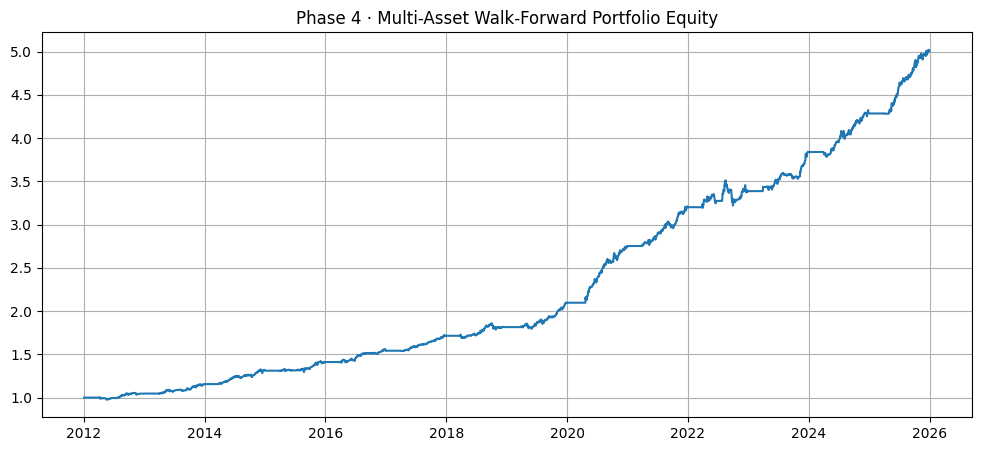

In [20]:
eq = (1 + portfolio["portfolio_ret"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(portfolio["date"], eq)
plt.title("Phase 4 · Multi-Asset Walk-Forward Portfolio Equity")
plt.grid(True)
plt.show()


In [21]:
def sharpe(x):
    return np.sqrt(252) * x.mean() / x.std() if x.std() > 0 else np.nan

summary = []

for y, g in portfolio.groupby("year"):
    eqy = (1 + g["portfolio_ret"]).cumprod()
    summary.append({
        "year": y,
        "sharpe": sharpe(g["portfolio_ret"]),
        "return": eqy.iloc[-1] - 1,
        "mdd": (eqy / eqy.cummax() - 1).min(),
        "avg_lev": g["portfolio_lev"].mean(),
    })

pd.DataFrame(summary)


,year,sharpe,return,mdd,avg_lev
0,2012,1.233654,0.047004,-0.029032,0.924000
1,2013,2.126118,0.104432,-0.021869,0.924603
2,2014,2.586903,0.134175,-0.031320,0.924603
3,2015,1.447841,0.076456,-0.028183,0.903516
4,2016,2.125802,0.092583,-0.019496,0.924603
5,2017,3.411194,0.111955,-0.009913,0.924303
6,2018,1.226804,0.058477,-0.038927,0.924303
7,2019,2.834056,0.155226,-0.032238,0.924603
8,2020,3.817514,0.312552,-0.029292,0.851879
9,2021,3.007791,0.163155,-0.025665,0.924603
